In [1]:
!pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 58.3 MB/s eta 0:00:00


In [2]:
#importing neccessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import surprise as sp
from surprise import SVD,accuracy,Dataset,Reader
from surprise.model_selection import train_test_split

# **Exploratory Data Analysis**

In [3]:
movies=pd.read_csv("/content/drive/MyDrive/Movie Reccomendation/movies.csv")
movies.head()


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings=pd.read_csv("/content/drive/MyDrive/Movie Reccomendation/ratings.csv")
ratings

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [5]:
tags=pd.read_csv("/content/drive/MyDrive/Movie Reccomendation/tags.csv")
tags.head(10)


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200
5,2,89774,Tom Hardy,1445715205
6,2,106782,drugs,1445715054
7,2,106782,Leonardo DiCaprio,1445715051
8,2,106782,Martin Scorsese,1445715056
9,7,48516,way too long,1169687325


In [6]:
#merging the neccessary tables
main_df=pd.merge(movies,ratings,on="movieId")
main_df.head(20)


,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,847434962
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,4.5,1106635946
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15,2.5,1510577970
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.5,1305696483
5,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,18,3.5,1455209816
6,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,19,4.0,965705637
7,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,21,3.5,1407618878
8,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,27,3.0,962685262
9,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,31,5.0,850466616


In [7]:
main_df.shape

(100836, 6)

In [8]:
#Getting info on the main df
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   movieId    100836 non-null  int64  
 1   title      100836 non-null  object 
 2   genres     100836 non-null  object 
 3   userId     100836 non-null  int64  
 4   rating     100836 non-null  float64
 5   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 4.6+ MB


All columns are **full** and **none are empty**

## **Top 10 Best Rated Movies**

In [9]:
#Top 10 best-rated Movies
rating_per_title=main_df.groupby("title")["rating"].mean()
top_movies=rating_per_title.sort_values(ascending=False)
top_movies.head(10)


,rating
title,
"Match Factory Girl, The (Tulitikkutehtaan tyttö) (1990)",5.0
Meantime (1984),5.0
"Decalogue, The (Dekalog) (1989)",5.0
"Stand, The (1994)",5.0
Big Top Scooby-Doo! (2012),5.0
I Am Not Your Negro (2017),5.0
Trinity and Sartana Are Coming (1972),5.0
Trailer Park Boys (1999),5.0
Bitter Lake (2015),5.0


## **Top 10 Most Rated Movies**

In [10]:
#Top 10 Most Rated movies
rt_t=main_df.groupby(["title"])["rating"].count()
rt_t=rt_t.sort_values(ascending=False)
rt_t.head(10)


,rating
title,
Forrest Gump (1994),329
"Shawshank Redemption, The (1994)",317
Pulp Fiction (1994),307
"Silence of the Lambs, The (1991)",279
"Matrix, The (1999)",278
Star Wars: Episode IV - A New Hope (1977),251
Jurassic Park (1993),238
Braveheart (1995),237
Terminator 2: Judgment Day (1991),224


## **Rating Distribution**

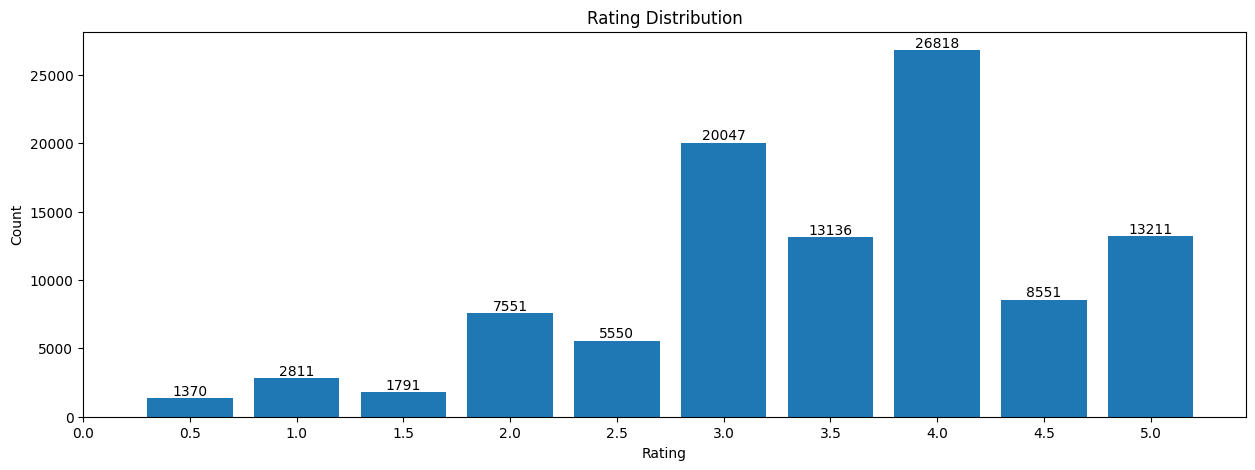

In [11]:
x_val=main_df["rating"].value_counts().index.to_list()
y_val=main_df["rating"].value_counts().values

plt.figure(figsize=(15,5))
bar1=plt.bar(x_val,y_val,width=0.4)
plt.bar_label(bar1,y_val)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution")
plt.xticks(np.arange(0.0, 5.1, 0.5))
plt.show()

# **Model Definition**

In [14]:
import time
x=main_df[["userId","movieId","rating"]]

# defining the rating range in reader and defining dataset
reader=Reader(rating_scale=(1,5))
ds=Dataset.load_from_df(x,reader)

train_set,test_set=train_test_split(ds,test_size=0.2)
model=SVD()

model.fit(train_set)
y=model.test(test_set)

#making a func for sorting the predicted rating in descending order
def est_sort(y_d):
  return y_d[3]

y.sort(key=est_sort,reverse=True)


#getting the unique movieIds
x=main_df["movieId"].value_counts()
x.index


uid=int(input("Enter your Id:"))
value_counter=0

for i in range(101):
  print(f"\rReccomending movies -- {i}%",end=" ",flush=True)
  time.sleep(0.02)


print(" ")
print("----------------------------------Reccomended Movies----------------------------------")

#logic for taking reccomended movies for a selected user
for i in range(len(y)):
  if y[i][0]==uid:
    for j in x.index:
      if y[i][1] == j:
          if value_counter < 6:
            print(f"{value_counter+1}.",(main_df.loc[(main_df["movieId"]==j) & (main_df["userId"]==uid),"title"].item()))

            value_counter+=1

print("-------------------------------------------------------------------------------------")





Enter your Id:6
Reccomending movies -- 100%  
----------------------------------Reccomended Movies----------------------------------
1. Bonnie and Clyde (1967)
2. Lion King, The (1994)
3. Usual Suspects, The (1995)
4. Ghost (1990)
5. Walk in the Clouds, A (1995)
6. Billy Madison (1995)
-------------------------------------------------------------------------------------


In [13]:
#running rmse
accuracy.rmse(y)

RMSE: 0.8824


np.float64(0.8823839343709728)

# **Summary:**

1. The **rmse** gave **0.8717** meaning the model is only **0.87** less accurate in its **predictions**.

2. The **model** remains constant and stable when giving random data to **train and test set**.

3. The **data** was overall **complete** meaning no extra **data prep** was required.

4. The **tags dataset** couldn't be used since it was conflicting with the other data sets in the **merging** and it wasn't required.

